# Q2 - Portfolio Effects: Property Demand focused

**Author:** Belinda (Gia Bao) Ngo

**Dataset:** `40B_zip_long_lat.csv` (https://drive.google.com/file/d/1n92fRXF_BWBSz2-vAPYDsduTz93VxYul/view?usp=drive_link)

**Instruction**: Download the CSV file above and move it to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [3]:
file_path = "../data/40B_zip_long_lat.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
print(len(df))
df = df[
    (df['current_residence_town_city'] != 'Unknown') &
    (df['current_residence_state'] != 'Unknown') &
    (df['age'] != 0) &
    (~df['hh_size'].isin([0, 20, 31]))
]
print(len(df))
df.head()

1619
1609


,id_number,submission_date,age,disability,chapa_races,census_races,current_residence_town_city,current_residence_state,current_residence_zip,application_source,...,race_white,property_lat,property_lon,current_lat,current_lon,distance_mi,current_county,property_county,local_applicant_county,local_applicant_town
0,150733,2022-02-08,65,0,White/Non-Minority,White alone,Somerville,MA,2145,Unknown,...,1,42.70,-71.11,42.39,-71.10,21.403626,Middlesex,Essex,0.0,0.0
1,439181,2022-02-08,59,0,Hispanic/Latino,Unknown,Westford,MA,1886,Unknown,...,0,42.70,-71.11,42.58,-71.43,18.290818,Middlesex,Essex,0.0,0.0
2,226436,2022-02-08,60,0,White/Non-Minority,White alone,Nashua,NH,3060,Unknown,...,1,42.70,-71.11,42.74,-71.45,17.523738,NaN,Essex,0.0,0.0
3,170029,2021-06-15,35,0,White/Non-Minority,White alone,Waltham,MA,2453,Unknown,...,1,42.48,-71.26,42.37,-71.24,7.661090,Middlesex,Middlesex,1.0,0.0
4,569863,2021-06-15,38,0,Black or African American,Black or African American alone,Woburn,MA,1801,Unknown,...,0,42.48,-71.26,42.48,-71.15,5.620161,Norfolk,Middlesex,0.0,0.0


In [4]:
# df.info()

## Visualizations

### Demand Pressure by Town (Applications per Property)

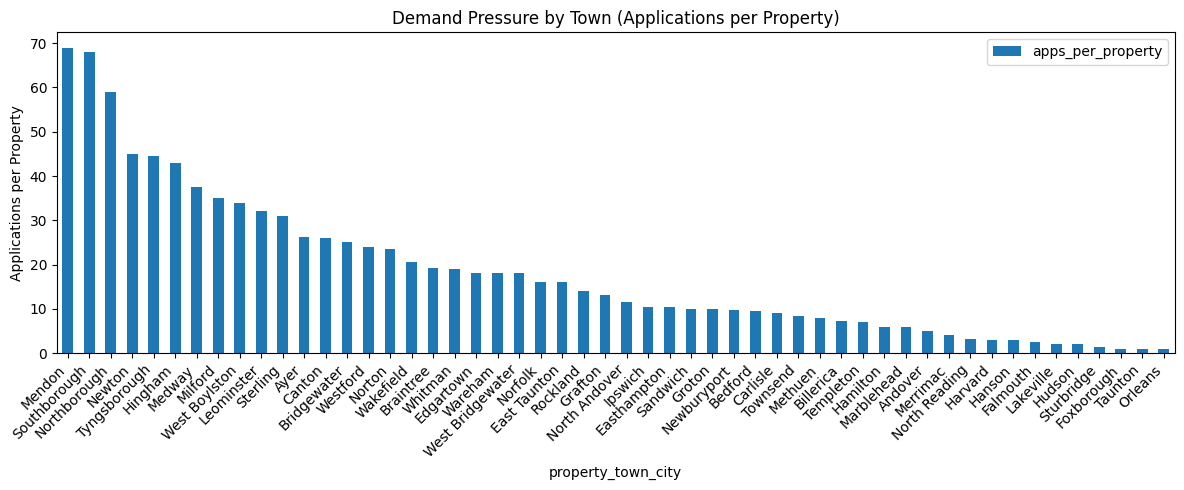

In [5]:
# Count unique properties per town
property_counts = (
    df.drop_duplicates(subset=["property_street_address", "property_unit", "property_town_city"])
      .groupby("property_town_city")
      .size()
      .reset_index(name="n_properties")
)
application_counts = (
    df.groupby("property_town_city")["id_number"]
      .count()
      .reset_index(name="n_applications")
)
town_summary = (
    property_counts
    .merge(application_counts, on="property_town_city", how="left")
)
town_summary["apps_per_property"] = town_summary["n_applications"] / town_summary["n_properties"]

town_summary.sort_values("apps_per_property", ascending=False)\
    .plot(x="property_town_city", y="apps_per_property",
          kind="bar", figsize=(12,5))

plt.ylabel("Applications per Property")
plt.title("Demand Pressure by Town (Applications per Property)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Applications vs. Number of Unique Properties by Town/City

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_34447/2985831968.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[['property_street_address', 'property_unit_clean']]


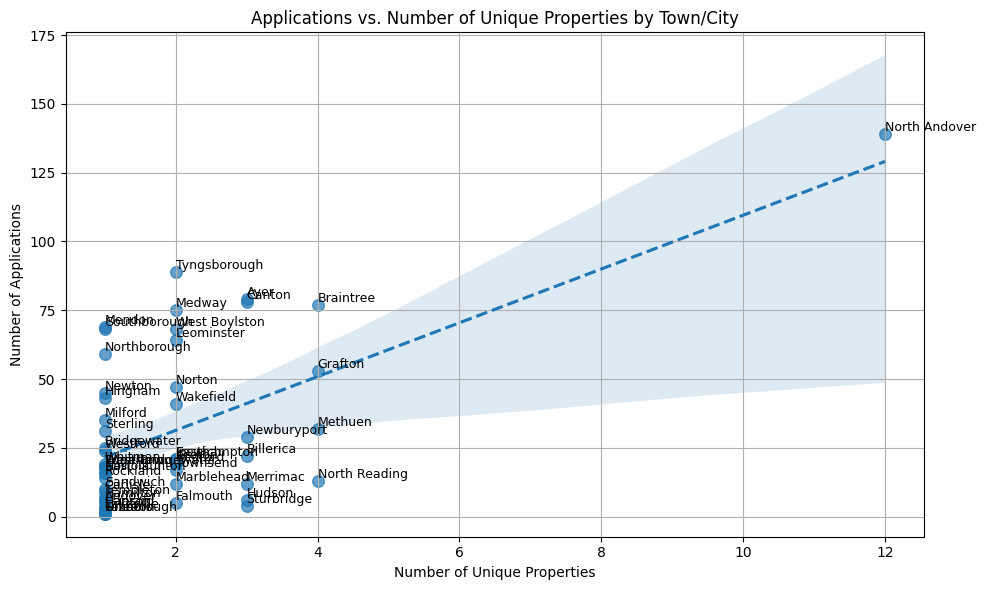

In [7]:
# Count unique properties per town (unique street + unit combos)
df['property_unit_clean'] = df['property_unit'].fillna('NO_UNIT').replace('', 'NO_UNIT')

properties_per_town = (
    df.groupby('property_town_city')
      .apply(lambda g: g[['property_street_address', 'property_unit_clean']]
             .drop_duplicates()
             .shape[0])
      .reset_index(name='num_properties')
)

# Count number of applications per town
applications_per_town = (
    df.groupby('property_town_city')
      .size()
      .reset_index(name='num_applications')
)

# Merge
town_summary = properties_per_town.merge(
    applications_per_town,
    on='property_town_city',
    how='left'
)

plt.figure(figsize=(10, 6))
sns.regplot(
    data=town_summary,
    x='num_properties',
    y='num_applications',
    scatter_kws={'s': 70, 'alpha': 0.7},
    line_kws={'linestyle': '--'}
)

# add labels to points
for _, row in town_summary.iterrows():
    plt.text(
        row['num_properties'],
        row['num_applications'],
        row['property_town_city'],
        fontsize=9,
        ha='left',
        va='bottom'
    )

plt.title("Applications vs. Number of Unique Properties by Town/City")
plt.xlabel("Number of Unique Properties")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

### Applications vs Properties by Town by Demographics

In [9]:
df['unique_property_key'] = (
    df['property_street_address'].astype(str).str.strip() + '|' +
    df['property_unit'].astype(str).str.strip() + '|' +
    df['property_town_city'].astype(str).str.strip()
)

# unique properties per town
property_counts = (
    df.drop_duplicates("unique_property_key")
      .groupby("property_town_city")["unique_property_key"]
      .nunique()
      .reset_index()
      .rename(columns={"unique_property_key": "n_properties"})
)

# applications per town
application_counts = (
    df.groupby("property_town_city")["application_id"]
      .nunique()
      .reset_index()
      .rename(columns={"application_id": "n_applications"})
)

# merge
town_stats = property_counts.merge(application_counts, on="property_town_city", how="left")

# applications per property
town_stats["apps_per_property"] = (
    town_stats["n_applications"] / town_stats["n_properties"]
)

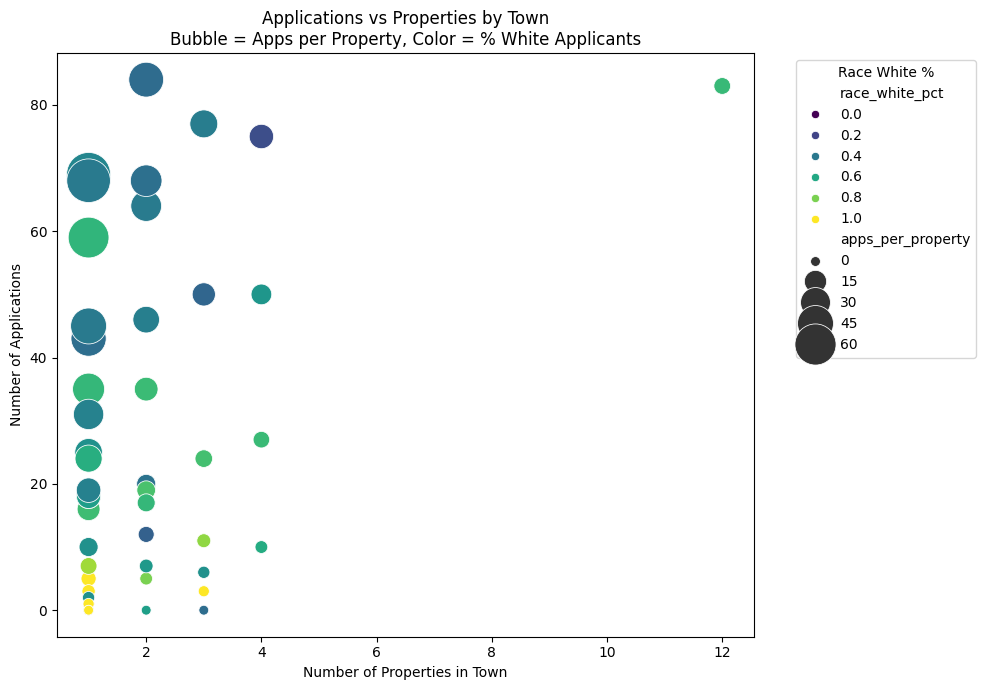

In [10]:
race_cols = [
    'race_american_indian_or_alaska_native',
    'race_asian',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_middle_eastern_or_north_african',
    'race_native_hawaiian_or_pacific_islander',
    'race_other__prefer_not_to_answer',
    'race_white'
]

race_town = df.groupby("property_town_city")[race_cols].sum().reset_index()
race_town["race_white_pct"] = race_town["race_white"] / race_town[race_cols].sum(axis=1)

# Merge into main table
town_stats_race = town_stats.merge(race_town[["property_town_city", "race_white_pct"]], 
                                   on="property_town_city", how="left")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=town_stats_race,
    x="n_properties",
    y="n_applications",
    size="apps_per_property",
    hue="race_white_pct",
    sizes=(50, 1000),
    palette="viridis"
)

plt.title("Applications vs Properties by Town\nBubble = Apps per Property, Color = % White Applicants")
plt.xlabel("Number of Properties in Town")
plt.ylabel("Number of Applications")
plt.legend(bbox_to_anchor=(1.05, 1), title="Race White %")
plt.tight_layout()
plt.show()

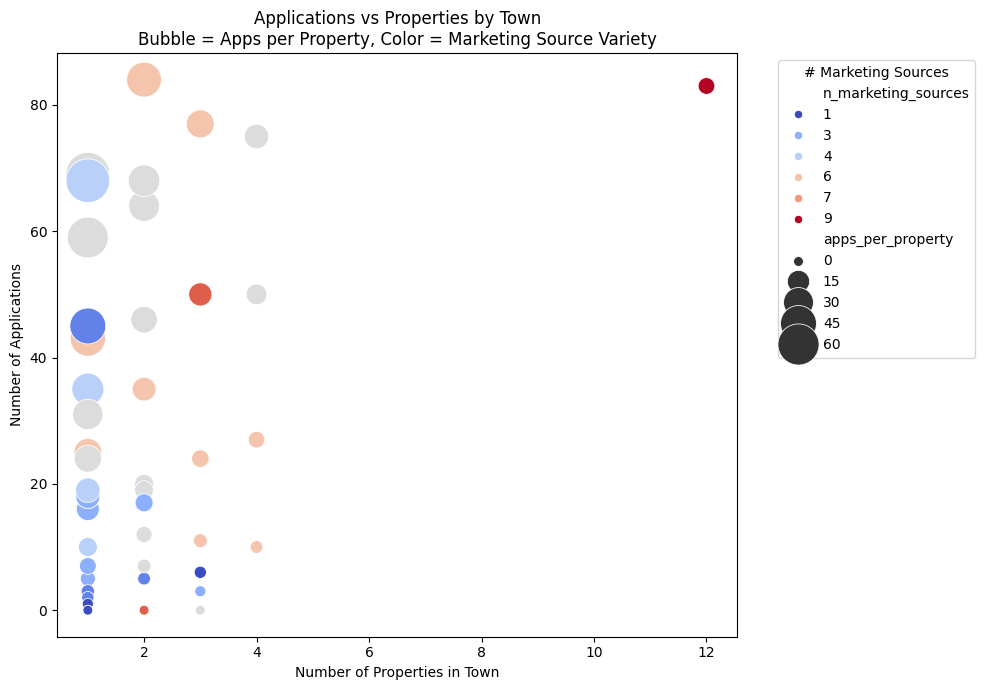

In [11]:
source_counts = (
    df.groupby("property_town_city")["application_source"]
      .nunique()
      .reset_index()
      .rename(columns={"application_source": "n_marketing_sources"})
)

town_stats_source = town_stats.merge(source_counts, on="property_town_city", how="left")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=town_stats_source,
    x="n_properties",
    y="n_applications",
    size="apps_per_property",
    hue="n_marketing_sources",
    sizes=(50, 1000),
    palette="coolwarm"
)

plt.title("Applications vs Properties by Town\nBubble = Apps per Property, Color = Marketing Source Variety")
plt.xlabel("Number of Properties in Town")
plt.ylabel("Number of Applications")
plt.legend(bbox_to_anchor=(1.05, 1), title="# Marketing Sources")
plt.tight_layout()
plt.show()